<a href="https://colab.research.google.com/github/minjxxyu0/ESAA/blob/main/YB_0403(2)_%E1%84%8B%E1%85%A7%E1%86%AB%E1%84%89%E1%85%B3%E1%86%B8%E1%84%86%E1%85%AE%E1%86%AB%E1%84%8C%E1%85%A6_%E1%84%91%E1%85%A7%E1%86%BC%E1%84%80%E1%85%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [ ]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, y_pred))

[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정확도 : (예측 결과가 동일한 데이터 건수) / (전체 예측 데이터 건수)

* 직관적으로 모델 예측 성능을 나타내는 평가 지표
* 모델이 전체적으로 얼마나 맞췄는지를 나타내는 지표

In [ ]:
from sklearn.metrics import accuracy_score

print(f"정확도: {accuracy_score(y, y_pred):.4f}")

정확도: 0.9121


**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정밀도 = TP / (FP + TP)

예측을 positive로 한 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율
실제 negative 음성인 데이터 예측을 positive 양성으로 잘못 판단하게 되면 업무상 큰 영향이 발생되는 경우에 중요함

In [ ]:
from sklearn.metrics import precision_score

print(f"정밀도: {precision_score(y, y_pred):.4f}")

정밀도: 0.9010


**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

재현율(Sensitivity/TPR) = TP / (FN + TP)

실제 값이 positive인 대상 중에서 예측과 실제 값이 positve로 일치한 데이터의 비율을
실제 positive 양성 데이터를 negative로 잘못 판단하게 되면 업무상 큰 영향이 발생되는 경우에 중요함

In [ ]:
from sklearn.metrics import recall_score

print(f"재현율: {recall_score(y, y_pred):.4f}")

재현율: 0.8585


**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

F1=2×(Precision+Recall) / (Precision×Recall​)

In [ ]:
from sklearn.metrics import f1_score

print(f"F1 score: {f1_score(y, y_pred):.4f}")

F1 score: 0.8792


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [ ]:
from sklearn.preprocessing import Binarizer
y_proba = model_lor.predict_proba(X)
y_proba_0 = y_proba[:, 0].reshape(-1, 1)

binarizer = Binarizer(threshold=0.1)
y_pred2_temp = binarizer.transform(y_proba_0)
y_pred2 = 1 - y_pred2_temp.flatten()

print(y_pred2[:10])

[1. 1. 1. 0. 1. 0. 1. 0. 0. 0.]


In [ ]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

cm2 = confusion_matrix(y, y_pred2)
acc2 = accuracy_score(y, y_pred2)
prec2 = precision_score(y, y_pred2)
rec2 = recall_score(y, y_pred2)
f1_2 = f1_score(y, y_pred2)

print("혼동행렬:\n", cm2)
print("정확도:", acc2)
print("정밀도:", prec2)
print("재현율:", rec2)
print("F1 score:", f1_2)

혼동행렬:
 [[356   1]
 [ 73 139]]
정확도: 0.8699472759226714
정밀도: 0.9928571428571429
재현율: 0.6556603773584906
F1 score: 0.7897727272727273


**ROC 곡선 시각화**

In [ ]:
from sklearn.metrics import roc_curve
y_pred_proba = model_lor.predict_proba(X)[:, 1]

# 임계값 변화에 따른 FPR, TPR 계산(fpr: 건강한데(0) 암이라고 잘못 예측한 비율, tpr: 1을 1로 찾아낸 비율)
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)

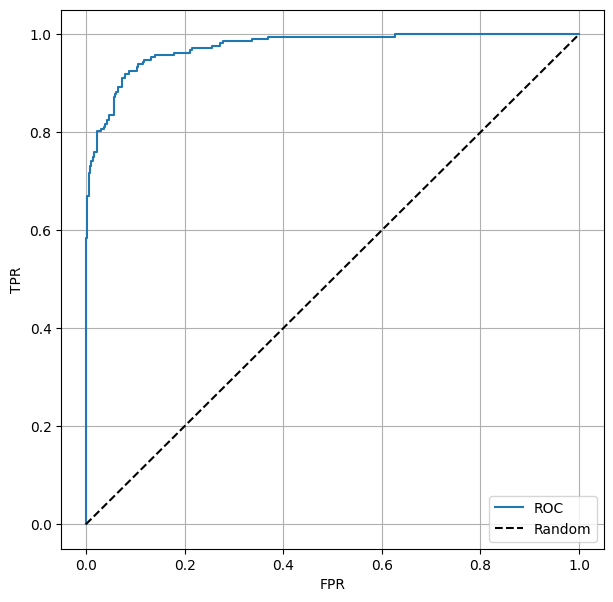

In [ ]:
import matplotlib.pyplot as plt
# 그래프 그리기
plt.figure(figsize=(7, 7))

# ROC 곡선
plt.plot(fpr, tpr, label='ROC')

# 기준선(검은 점선은 무작위로 추측했을 때의 성능을 의미함, 점선보다 roc가 위에 있기에 유의미하다고 할 수 있음)
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [ ]:
pred_proba = model_lor.predict_proba(X)
auc = roc_auc_score(y, pred_proba[:, 1])

print("ROC AUC:", auc)

ROC AUC: 0.974076423022039
